In [737]:
import os, sys
import yaml
import pandas as pd

# Set working directory
os.chdir(r"C:\Users\samue\OneDrive\Desktop\BSQ\HP\hurst-pullback")
sys.path.append(os.getcwd())

print("CWD:", os.getcwd())

# Correct path to YAML
yaml_path = "./configs/base.yaml"
with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

# Load dataset
base_dir = os.getcwd()
full_path = os.path.join(base_dir, config["data"]["raw_NQ"])

df = pd.read_csv(full_path)

CWD: C:\Users\samue\OneDrive\Desktop\BSQ\HP\hurst-pullback


In [738]:
df["Returns"] = df["Close"] / df["Close"].shift(1) - 1
df.head()


,Date,Close,High,Low,Open,Vol,Returns
0,2000-09-18,3653.5,3785.5,3602.0,3721.0,72994.0,NaN
1,2000-09-19,3804.0,3817.0,3656.0,3658.5,70029.0,0.041193
2,2000-09-20,3853.0,3874.0,3715.5,3801.5,78832.0,0.012881
3,2000-09-21,3765.0,3874.0,3744.0,3852.0,70719.0,-0.022839
4,2000-09-22,3776.0,3780.0,3615.0,3673.0,55926.0,0.002922


In [739]:
df["Returns"] = df["Close"] / df["Close"].shift(1)
df.head()
X = df["Returns"].dropna()

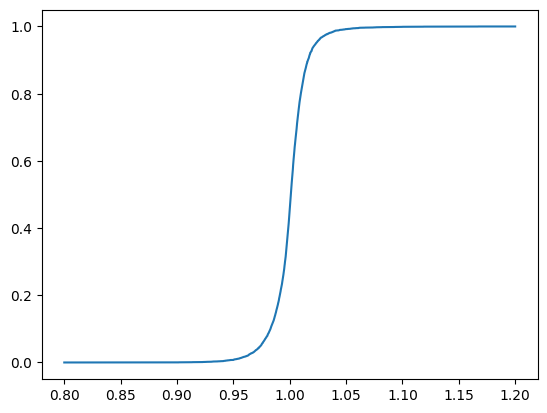

In [740]:

from scipy.stats import ecdf
emp_cdf=lambda x: ecdf(X).cdf.evaluate(x)

from matplotlib import pyplot as plt
import numpy as np

t = np.linspace(0.8, 1.20, 10000)
plt.plot(t, emp_cdf(t))
plt.show()

(1, 6314)


(array([4.000e+00, 3.000e+01, 2.660e+02, 3.100e+03, 2.709e+03, 1.600e+02,
        2.700e+01, 1.100e+01, 6.000e+00, 1.000e+00]),
 array([0.8915805 , 0.9191254 , 0.9466703 , 0.97421521, 1.00176011,
        1.02930501, 1.05684991, 1.08439482, 1.11193972, 1.13948462,
        1.16702952]),
 <BarContainer object of 10 artists>)

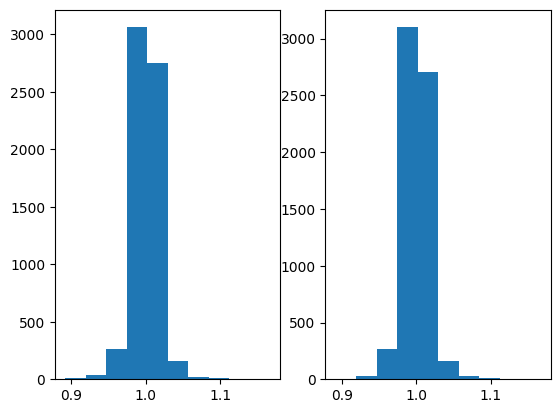

In [741]:
Z = []
for i in range(1):
    Y = np.random.rand(len(X))
    F_sorted = emp_cdf(t)
    def inverse_cdf(u, x, F):
        return np.interp(u, F, x)
    Z.append(inverse_cdf(Y,t,F_sorted))
Z = np.array(Z)
print(Z.shape)
Y = Z.mean(axis = 0)    
plt.subplot(1,2,1)
plt.hist(X)
plt.subplot(1,2,2)
plt.hist(Y)

In [ ]:
X = X - 1
Y = Y - 1
Y = Y + (X.mean() - Y.mean())
print(X.mean())
print(Y.mean())
print(X.std())
print(Y.std())

0.0004435974549394659
0.00044864163939984536
0.01632198912125694
0.016590331272741787


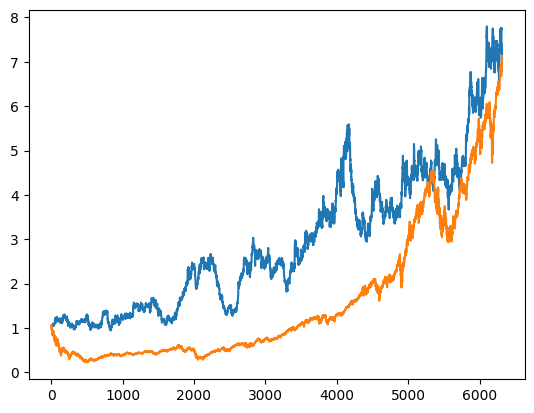

In [743]:
from src.core.metrics import cumulative_return
Y = pd.Series(Y).dropna()
eqY = cumulative_return(Y)
eqX = cumulative_return(X)

plt.figure()
plt.plot(eqY)
plt.plot(eqX)


In [744]:


  # shape (T,)
seq_len = 50

# costruisci dataset
sequences = np.array([
    X[i:i+seq_len] for i in range(len(X) - seq_len)
])

# reshape per aggiungere la dimensione delle feature
sequences = sequences.reshape(-1, seq_len, 1)

print(sequences.shape)


(6264, 50, 1)


In [745]:
from ydata_synthetic.synthesizers.timeseries import TimeGAN

# real_data: array shape (n_sequences, seq_len, n_features)
model = TimeGAN(seq_len=50, batch_size=128)
model.fit(real_data)

synthetic_data = model.sample(n_samples=1000)

ModuleNotFoundError: No module named 'ydata_synthetic'